In [344]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import torch
import torch.nn as nn

In [345]:
LATENT_DIM = 128

In [346]:
windows = np.load(
    "/home/iailab42/khans1/projects/data/s1_windows.npy"
)

print(windows.shape)

(2302, 512, 6)


In [347]:
for i, name in enumerate(
    ["BVP","ACC_X","ACC_Y","ACC_Z","EDA","TEMP"]
):
    print(name)
    print("mean =", windows[:,:,i].mean())
    print("std  =", windows[:,:,i].std())
    print("min  =", windows[:,:,i].min())
    print("max  =", windows[:,:,i].max())
    print()

BVP
mean = -0.0008238759774109209
std  = 97.14216216490856
min  = -1647.39
max  = 1557.58

ACC_X
mean = -0.49345308691037987
std  = 0.2787408921894297
min  = -2.0
max  = 1.984375

ACC_Y
mean = 0.09403314316204173
std  = 0.5951295995444198
min  = -1.8879936726866142
max  = 1.984375

ACC_Z
mean = 0.5515331081887557
std  = 0.366257008550744
min  = -2.0
max  = 1.984375

EDA
mean = 5.456566037513433
std  = 2.9421611959381386
min  = 2.21759643143526
max  = 17.872802671865987

TEMP
mean = 32.65995092273073
std  = 1.5316015378800127
min  = 29.09
max  = 34.61



### Normalization

In [348]:
windows_normalized = windows.copy()

channel_means = []
channel_stds = []

In [349]:
for channel in range(6):

    mean = windows[:,:,channel].mean()
    std = windows[:,:,channel].std()

    channel_means.append(mean)
    channel_stds.append(std)

    windows_normalized[:,:,channel] = (
        windows[:,:,channel] - mean
    ) / std

In [350]:
channel_names = [
    "BVP",
    "ACC_X",
    "ACC_Y",
    "ACC_Z",
    "EDA",
    "TEMP"
]

for i, name in enumerate(channel_names):

    print(name)

    print(
        "mean =",
        windows_normalized[:,:,i].mean()
    )

    print(
        "std =",
        windows_normalized[:,:,i].std()
    )

    print()

BVP
mean = 4.069290517061146e-19
std = 1.0000000000000002

ACC_X
mean = 1.882845650797833e-16
std = 1.0

ACC_Y
mean = 0.0
std = 1.0000000000000002

ACC_Z
mean = -2.8397016372688625e-16
std = 1.0

EDA
mean = -9.877223086152565e-17
std = 1.0

TEMP
mean = -3.358255849291872e-15
std = 1.0



In [351]:
channel_means = np.array(channel_means)
channel_stds = np.array(channel_stds)

print(channel_means)
print(channel_stds)

[-8.23875977e-04 -4.93453087e-01  9.40331432e-02  5.51533108e-01
  5.45656604e+00  3.26599509e+01]
[97.14216216  0.27874089  0.5951296   0.36625701  2.9421612   1.53160154]


In [352]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.12.0+cu130
CUDA available: True
GPU: NVIDIA RTX A6000


In [353]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    windows_normalized,
    test_size=0.2,
    random_state=42
)

print("Train:", train_data.shape)
print("Test :", test_data.shape)

Train: (1841, 512, 6)
Test : (461, 512, 6)


In [354]:
train_data = np.transpose(
    train_data,
    (0,2,1)
)

test_data = np.transpose(
    test_data,
    (0,2,1)
)

print("Train:", train_data.shape)
print("Test :", test_data.shape)

Train: (1841, 6, 512)
Test : (461, 6, 512)


In [355]:
train_tensor = torch.tensor(
    train_data,
    dtype=torch.float32
)

test_tensor = torch.tensor(
    test_data,
    dtype=torch.float32
)

print(train_tensor.shape)
print(test_tensor.shape)

torch.Size([1841, 6, 512])
torch.Size([461, 6, 512])


In [356]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_tensor)
test_dataset = TensorDataset(test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches :", len(test_loader))

Train batches: 29
Test batches : 8


In [357]:
batch = next(iter(train_loader))

print(type(batch))

print(len(batch))

print(batch[0].shape)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

<class 'list'>
1
torch.Size([64, 6, 512])
cuda


In [358]:
class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv1d(
                in_channels=6,
                out_channels=16,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.ReLU()
        )
        self.flatten = nn.Flatten()

        self.fc = nn.Linear(32 * 128, 128)

        self.mu = nn.Linear(128, LATENT_DIM)
        self.logvar = nn.Linear(128, LATENT_DIM)
    
    def forward(self, x):
    
        x = self.conv1(x)
        x = self.flatten(x)
        
        x = self.fc(x)

        mu = self.mu(x)
        logvar = self.logvar(x)
        
        return mu, logvar

In [359]:
encoder = Encoder()

batch = next(iter(train_loader))[0]

print("Input Shape: ", batch.shape)

mu, logvar = encoder(batch)
print("mu shape:", mu.shape)

print("logvar shape:", logvar.shape)

Input Shape:  torch.Size([64, 6, 512])
mu shape: torch.Size([64, 128])
logvar shape: torch.Size([64, 128])


In [360]:
def reparameterize(mu, logvar):

    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)

    z = mu + eps * std

    return z   

In [361]:
z = reparameterize(mu, logvar)

print("z shape:", z.shape)

z shape: torch.Size([64, 128])


In [362]:
class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(LATENT_DIM, 128)
        self.fc2 = nn.Linear(128, 32 * 128)

        self.unflatten = nn.Unflatten(
            dim=1,
            unflattened_size=(32, 128)
        )

        self.deconv = nn.Sequential(

        nn.ConvTranspose1d(
            in_channels=32,
            out_channels=16,
            kernel_size=4,
            stride=2,
            padding=1
        ),

        nn.ReLU(),

        nn.ConvTranspose1d(
            in_channels=16,
            out_channels=6,
            kernel_size=4,
            stride=2,
            padding=1
        )
)

    def forward(self, z):

        z = self.fc1(z)
        z = self.fc2(z)

        z = self.unflatten(z)

        z = self.deconv(z)

        return z

In [363]:
decoder = Decoder()

reconstructed = decoder(z)

print(reconstructed.shape)

torch.Size([64, 6, 512])


In [364]:
class VAE(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        z = mu + eps * std

        return z

    def forward(self, x):

        mu, logvar = self.encoder(x)

        z = self.reparameterize(mu, logvar)

        reconstructed = self.decoder(z)

        return reconstructed, mu, logvar    

In [365]:
def vae_loss(reconstruction, x, mu, logvar):

    # Reconstruction Loss
    recon_loss = nn.functional.mse_loss(
        reconstruction,
        x,
        reduction="mean"
    )

    # KL Divergence Loss
    kl_loss = -0.5 *torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    # Total Loss
    # total_loss = recon_loss + kl_loss
    BETA = 0.01

    total_loss = recon_loss + BETA * kl_loss

    return total_loss, recon_loss, kl_loss

In [366]:
# model = VAE()

# batch = next(iter(train_loader))[0]

# reconstruction, mu, logvar = model(batch)

# total_loss, recon_loss, kl_loss = vae_loss(
#     reconstruction,
#     batch,
#     mu,
#     logvar
# )

# print("Input Shape:         ", batch.shape)
# print("Reconstruction Shape:", reconstruction.shape)
# print("mu Shape:            ", mu.shape)
# print("logvar Shape:        ", logvar.shape)

# print("======= Loss =======")

# print("Total Loss:", total_loss.item())
# print("Recon Loss:", recon_loss.item())
# print("KL Loss:", kl_loss.item())

In [367]:
model = VAE().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [368]:
def train_vae(model,
              train_loader,
              optimizer,
              device,
              num_epochs=10):

    train_losses = []

    for epoch in range(num_epochs):

        model.train()

        running_loss = 0.0
        running_recon_loss = 0.0
        running_kl_loss = 0.0

        for batch in train_loader:

            x = batch[0].to(device)

            optimizer.zero_grad()

            reconstruction, mu, logvar = model(x)

            total_loss, recon_loss, kl_loss = vae_loss(
                reconstruction,
                x,
                mu,
                logvar
            )

            total_loss.backward()

            optimizer.step()

            running_loss += total_loss.item()
            running_recon_loss += recon_loss.item()
            running_kl_loss += kl_loss.item()

        avg_loss = running_loss / len(train_loader)
        avg_recon_loss = running_recon_loss / len(train_loader)
        avg_kl_loss = running_kl_loss / len(train_loader)

        train_losses.append(avg_loss)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Loss: {avg_loss:.4f} "
            f"Recon Loss: {avg_recon_loss:.4f} "
            f"KL Loss: {avg_kl_loss:.4f}"
        )

    return train_losses

In [369]:
train_vae(
    model=model,
    train_loader=train_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=75
)

Epoch [1/75] Loss: 0.8812 Recon Loss: 0.8762 KL Loss: 0.5034


Epoch [2/75] Loss: 0.6320 Recon Loss: 0.6235 KL Loss: 0.8431
Epoch [3/75] Loss: 0.4689 Recon Loss: 0.4598 KL Loss: 0.9076
Epoch [4/75] Loss: 0.4160 Recon Loss: 0.4063 KL Loss: 0.9624
Epoch [5/75] Loss: 0.3892 Recon Loss: 0.3795 KL Loss: 0.9678
Epoch [6/75] Loss: 0.3677 Recon Loss: 0.3579 KL Loss: 0.9847
Epoch [7/75] Loss: 0.3496 Recon Loss: 0.3397 KL Loss: 0.9870
Epoch [8/75] Loss: 0.3379 Recon Loss: 0.3280 KL Loss: 0.9918
Epoch [9/75] Loss: 0.3291 Recon Loss: 0.3189 KL Loss: 1.0148
Epoch [10/75] Loss: 0.3221 Recon Loss: 0.3120 KL Loss: 1.0126
Epoch [11/75] Loss: 0.3177 Recon Loss: 0.3075 KL Loss: 1.0178
Epoch [12/75] Loss: 0.3137 Recon Loss: 0.3036 KL Loss: 1.0097
Epoch [13/75] Loss: 0.3053 Recon Loss: 0.2950 KL Loss: 1.0333
Epoch [14/75] Loss: 0.2945 Recon Loss: 0.2838 KL Loss: 1.0719
Epoch [15/75] Loss: 0.2786 Recon Loss: 0.2671 KL Loss: 1.1514
Epoch [16/75] Loss: 0.2589 Recon Loss: 0.2463 KL Loss: 1.2638
Epoch [17/75] Loss: 0.2383 Recon Loss: 0.2245 KL Loss: 1.3793
Epoch [18/75] Lo

[0.88121275244088,
 0.6319647893823427,
 0.46890223951175297,
 0.4159511543553451,
 0.3892227565420085,
 0.36773854083028334,
 0.34957435727119446,
 0.33790581801842,
 0.32908413225206834,
 0.322104804474732,
 0.3176560001126651,
 0.3137242249373732,
 0.30529172872674876,
 0.2945292268333764,
 0.278596544574047,
 0.2589203828367694,
 0.23834029559431405,
 0.22316495046533388,
 0.20964535094540696,
 0.19633464874892398,
 0.18670939217353688,
 0.17788222586286478,
 0.17074721691937284,
 0.16619084878214474,
 0.16189327476353482,
 0.15812698725996346,
 0.15619002488152733,
 0.1520307857928605,
 0.14933688681701135,
 0.1469244260726304,
 0.14385318499186944,
 0.14214448605118127,
 0.1404740995374219,
 0.1388433675827651,
 0.13661914627099858,
 0.1341992256970241,
 0.1334347267603052,
 0.1333217523221312,
 0.13086801484741015,
 0.12889378055416303,
 0.12715367279176054,
 0.1258916654463472,
 0.12536346706850776,
 0.12324499929773397,
 0.12190831015849936,
 0.12170243237552972,
 0.1203590184

In [370]:
def evaluate_full_test(model, test_loader, device):

    model.eval()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    with torch.no_grad():

        for batch in test_loader:

            x = batch[0].to(device)

            reconstruction, mu, logvar = model(x)

            loss, recon_loss, kl_loss = vae_loss(
                reconstruction,
                x,
                mu,
                logvar
            )

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()

    avg_loss = total_loss / len(test_loader)
    avg_recon = total_recon / len(test_loader)
    avg_kl = total_kl / len(test_loader)

    print("===== FULL TEST SET EVALUATION =====")
    print(f"Test Loss      : {avg_loss:.6f}")
    print(f"Test Recon Loss: {avg_recon:.6f}")
    print(f"Test KL Loss   : {avg_kl:.6f}")

    return avg_loss, avg_recon, avg_kl

In [371]:
evaluate_full_test(
    model=model,
    test_loader=test_loader,
    device=device
)

===== FULL TEST SET EVALUATION =====
Test Loss      : 0.134562
Test Recon Loss: 0.117443
Test KL Loss   : 1.711989


(0.13456240016967058, 0.11744250915944576, 1.711989387869835)

In [372]:
# batch = next(iter(test_loader))[0].to(device)

# model.eval()

# with torch.no_grad():

#     reconstruction, mu, logvar = model(batch)

In [373]:
# sample_idx = 0

# original = batch[sample_idx].cpu().numpy()
# reconstructed = reconstruction[sample_idx].cpu().numpy()

# plt.figure(figsize=(12,4))

# plt.plot(original[0], label="Original BVP")
# plt.plot(reconstructed[0], label="Reconstructed BVP")

# plt.legend()
# plt.show()

In [374]:
# print(reconstructed[0].min(), reconstructed[0].max())
# print(original[0].min(), original[0].max())

# print(batch.mean().item())
# print(batch.std().item())

# print(reconstruction.mean().item())
# print(reconstruction.std().item())

In [375]:
# channels = [
#     "BVP",
#     "ACC_X",
#     "ACC_Y",
#     "ACC_Z",
#     "EDA",
#     "TEMP"
# ]

# for i, name in enumerate(channels):

#     print(
#         name,
#         "orig std =", original[i].std(),
#         "recon std =", reconstructed[i].std()
#     )

In [376]:
# print(mu.mean().item())
# print(mu.std().item())

# print(logvar.mean().item())
# print(logvar.std().item())

In [ ]:
# torch.save(
#     model.state_dict(),
#     "/home/iailab42/khans1/projects/models/vae_s1_latent128_beta001_epoch75.pth"
# )

In [ ]:
# import json

# with open(
#     "/home/iailab42/khans1/projects/results/latent128_beta001_epoch75/train_losses.json",
#     "w"
# ) as f:
#     json.dump(train_losses, f)

In [387]:
import os

def evaluate_vae_one_batch(
    model,
    test_loader,
    device,
    experiment_name
):

    result_dir = f"/home/iailab42/khans1/projects/results/{experiment_name}"

    os.makedirs(result_dir, exist_ok=True)

    model.eval()

    batch = next(iter(test_loader))[0].to(device)

    with torch.no_grad():

        reconstruction, mu, logvar = model(batch)

    sample_idx = 0

    original = batch[sample_idx].cpu().numpy()
    reconstructed = reconstruction[sample_idx].cpu().numpy()

    # ==========================
    # Save BVP Plot
    # ==========================

    plt.figure(figsize=(12,4))

    plt.plot(
        original[0],
        label="Original BVP"
    )

    plt.plot(
        reconstructed[0],
        label="Reconstructed BVP"
    )

    plt.legend()

    plt.title(
        f"BVP Reconstruction - {experiment_name}"
    )

    plot_path = (
        f"{result_dir}/bvp_reconstruction.png"
    )

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    plt.figure(figsize=(12,4))

    plt.plot(
        original[1],
        label="Original ACC_X"
    )

    plt.plot(
        reconstructed[1],
        label="Reconstructed ACC_X"
    )

    plt.legend()

    plt.title(
        f"ACC_X Reconstruction - {experiment_name}"
    )

    plot_path = (
        f"{result_dir}/acc_x_reconstruction.png"
    )

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    # ==========================
    # Statistics
    # ==========================

    channels = [
        "BVP",
        "ACC_X",
        "ACC_Y",
        "ACC_Z",
        "EDA",
        "TEMP"
    ]

    report_lines = []

    report_lines.append(
        f"Experiment: {experiment_name}\n"
    )

    report_lines.append(
        "=" * 60 + "\n"
    )

    report_lines.append(
        "LATENT SPACE STATISTICS\n"
    )

    report_lines.append(
        f"mu mean      : {mu.mean().item():.6f}\n"
    )

    report_lines.append(
        f"mu std       : {mu.std().item():.6f}\n"
    )

    report_lines.append(
        f"logvar mean  : {logvar.mean().item():.6f}\n"
    )

    report_lines.append(
        f"logvar std   : {logvar.std().item():.6f}\n\n"
    )

    report_lines.append(
        "GLOBAL RECONSTRUCTION STATISTICS\n"
    )

    report_lines.append(
        f"Original Mean       : {batch.mean().item():.6f}\n"
    )

    report_lines.append(
        f"Original Std        : {batch.std().item():.6f}\n"
    )

    report_lines.append(
        f"Reconstruction Mean : {reconstruction.mean().item():.6f}\n"
    )

    report_lines.append(
        f"Reconstruction Std  : {reconstruction.std().item():.6f}\n\n"
    )

    report_lines.append(
        "BVP RANGE\n"
    )

    report_lines.append(
        f"Original Min : {original[0].min():.6f}\n"
    )

    report_lines.append(
        f"Original Max : {original[0].max():.6f}\n"
    )

    report_lines.append(
        f"Recon Min    : {reconstructed[0].min():.6f}\n"
    )

    report_lines.append(
        f"Recon Max    : {reconstructed[0].max():.6f}\n\n"
    )

    report_lines.append(
        "CHANNEL-WISE STANDARD DEVIATION\n"
    )

    for i, name in enumerate(channels):

        report_lines.append(
            f"{name:<8}"
            f" Original STD: {original[i].std():.6f}"
            f" | Recon STD: {reconstructed[i].std():.6f}\n"
        )

    report_path = (
        f"{result_dir}/evaluation_report.txt"
    )

    with open(
        report_path,
        "w"
    ) as f:

        f.writelines(report_lines)

    print(
        f"Results saved to:\n{result_dir}"
    )

    print(
        f"Plot:\n{plot_path}"
    )

    print(
        f"Report:\n{report_path}"
    )

    return {
        "mu_mean": mu.mean().item(),
        "mu_std": mu.std().item(),
        "logvar_mean": logvar.mean().item(),
        "logvar_std": logvar.std().item(),
        "original_std": batch.std().item(),
        "reconstruction_std": reconstruction.std().item()
    }

Results saved to:
/home/iailab42/khans1/projects/results/latent128_beta001_epoch75
Plot:
/home/iailab42/khans1/projects/results/latent128_beta001_epoch75/acc_x_reconstruction.png
Report:
/home/iailab42/khans1/projects/results/latent128_beta001_epoch75/evaluation_report.txt


{'mu_mean': 0.004659165628254414,
 'mu_std': 0.9084708094596863,
 'logvar_mean': -3.3946146965026855,
 'logvar_std': 1.1813609600067139,
 'original_std': 0.9335772395133972,
 'reconstruction_std': 0.8831737637519836}

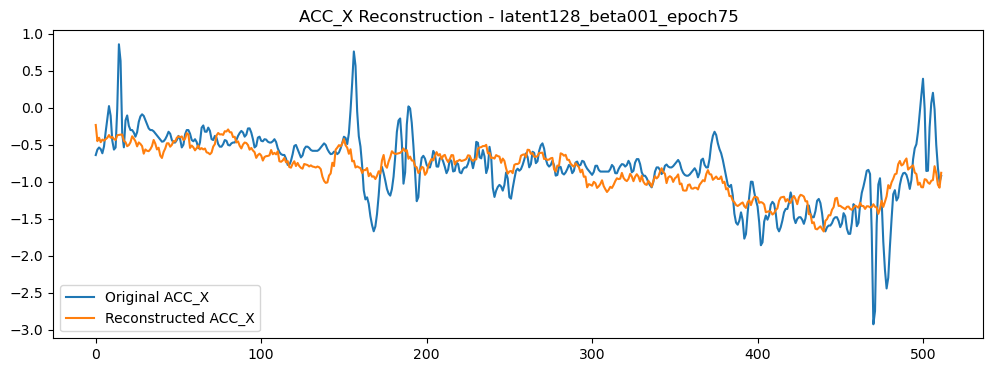

In [388]:
evaluate_vae_one_batch(
    model=model,
    test_loader=test_loader,
    device=device,
    experiment_name="latent128_beta001_epoch75"
)